# **Emo-Track**

Import Libraries

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
from google.colab import drive
import os
import scipy.io.wavfile
import numpy as np
import pandas as pd
import numpy
import joblib
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix

Mount Google Drive

In [ ]:
drive.mount("/content/gdrive")

Mounted at /content/gdrive


Dataset Path

In [ ]:
my_path = '/content/gdrive/MyDrive/SER_Dataset'

In [ ]:
my_data = os.listdir(my_path)

Load a sample audio file and Visualize its waveform


In [ ]:
data, sampling_rate = librosa.load(my_path+'/03-01-01-01-02-01-03.wav')

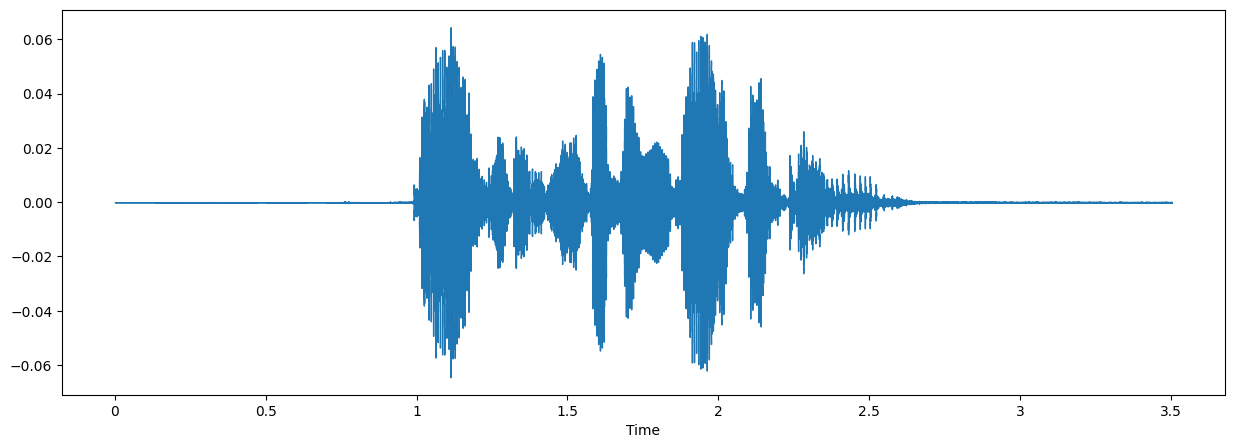

In [ ]:
plt.figure(figsize=(15, 5))
librosa.display.waveshow(data, sr=sampling_rate)

Feature Extraction

In [ ]:
emotions_num = ["Neutral-01","Calm-02","Happy-03","Sad-04","Angry-05","Fearful-06","Disgust-07","Surprised-08"]
actors = ["01","02","03","04","05","06","07","08","09","10","11","12","13","14","15","16","17","18","19","20","21","22","23","24"]

Mean and Standard Deviation of:

*   Mel - Frequency Cepstral Coefficients (MFCC)
*   Modulation Spectrogram
*   Zero Crossing Rate (ZCR)





In [ ]:
n_mfcc = 39
n_mels=256
hop_length=512
fmax=8000

def feature_extraction(path, modal_vocal, emotions_num, actors):
    labels = []   # Emotion names

    # Mean and Standard deviation of MFCC
    mean_mfcc_features = []
    std_mfcc_features = []

    # Mean and Standard deviation of Modulation Spectrogram
    mean_ms_features = []
    std_ms_features = []

    # Mean and Standard deviation of ZCR
    mean_zcr_features = []
    std_zcr_features = []

    # Repetition : 1 | Statement : 1 | Emotional Intensity : 1
    for index1,emotion_num in enumerate(emotions_num):
        for index,actor in enumerate(actors):
            x, sr = librosa.load(path+modal_vocal+emotion_num[-2:]+"-01-01-01-"+actor+".wav", sr=44100)
            mean_mfccs = np.mean(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=n_mfcc).T,axis=0)
            std_mfccs = np.std(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=n_mfcc).T,axis=0)
            mean_mfcc_features.append(mean_mfccs)
            std_mfcc_features.append(std_mfccs)

            modulation_spectrogram = librosa.feature.melspectrogram(y=x, sr=sr, n_mels=n_mels, hop_length=hop_length, fmax=fmax)
            modulation_spectrogram_db = librosa.power_to_db(modulation_spectrogram, ref=np.max)
            mean_modulation_spectrogram = np.mean(modulation_spectrogram_db, axis=1)
            std_modulation_spectrogram = np.std(modulation_spectrogram_db, axis=1)
            mean_ms_features.append(mean_modulation_spectrogram)
            std_ms_features.append(std_modulation_spectrogram)

            zcr = librosa.feature.zero_crossing_rate(x)
            mean_zcr = np.mean(zcr)
            std_zcr = np.std(zcr)
            mean_zcr_features.append(mean_zcr)
            std_zcr_features.append(std_zcr)

            labels.append(emotion_num[:-3])

    # Repetition : 1 | Statement : 2 | Emotional Intensity : 1
    for index1,emotion_num in enumerate(emotions_num):
        for index,actor in enumerate(actors):
            x, sr = librosa.load(path+modal_vocal+emotion_num[-2:]+"-01-02-01-"+actor+".wav", sr=44100)
            mean_mfccs = np.mean(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=n_mfcc).T,axis=0)
            std_mfccs = np.std(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=n_mfcc).T,axis=0)
            mean_mfcc_features.append(mean_mfccs)
            std_mfcc_features.append(std_mfccs)

            modulation_spectrogram = librosa.feature.melspectrogram(y=x, sr=sr, n_mels=n_mels, hop_length=hop_length, fmax=fmax)
            modulation_spectrogram_db = librosa.power_to_db(modulation_spectrogram, ref=np.max)
            mean_modulation_spectrogram = np.mean(modulation_spectrogram_db, axis=1)
            std_modulation_spectrogram = np.std(modulation_spectrogram_db, axis=1)
            mean_ms_features.append(mean_modulation_spectrogram)
            std_ms_features.append(std_modulation_spectrogram)

            zcr = librosa.feature.zero_crossing_rate(x)
            mean_zcr = np.mean(zcr)
            std_zcr = np.std(zcr)
            mean_zcr_features.append(mean_zcr)
            std_zcr_features.append(std_zcr)

            labels.append(emotion_num[:-3])

    # Repetition : 2 | Statement : 1 | Emotional Intensity : 1
    for index1,emotion_num in enumerate(emotions_num):
        for index,actor in enumerate(actors):
            x, sr = librosa.load(path+modal_vocal+emotion_num[-2:]+"-01-01-02-"+actor+".wav", sr=44100)
            mean_mfccs = np.mean(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=n_mfcc).T,axis=0)
            std_mfccs = np.std(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=n_mfcc).T,axis=0)
            mean_mfcc_features.append(mean_mfccs)
            std_mfcc_features.append(std_mfccs)

            modulation_spectrogram = librosa.feature.melspectrogram(y=x, sr=sr, n_mels=n_mels, hop_length=hop_length, fmax=fmax)
            modulation_spectrogram_db = librosa.power_to_db(modulation_spectrogram, ref=np.max)
            mean_modulation_spectrogram = np.mean(modulation_spectrogram_db, axis=1)
            std_modulation_spectrogram = np.std(modulation_spectrogram_db, axis=1)
            mean_ms_features.append(mean_modulation_spectrogram)
            std_ms_features.append(std_modulation_spectrogram)

            zcr = librosa.feature.zero_crossing_rate(x)
            mean_zcr = np.mean(zcr)
            std_zcr = np.std(zcr)
            mean_zcr_features.append(mean_zcr)
            std_zcr_features.append(std_zcr)

            labels.append(emotion_num[:-3])

    # Repetition : 2 | Statement : 2 | Emotional Intensity : 1
    for index1,emotion_num in enumerate(emotions_num):
        for index,actor in enumerate(actors):
            x, sr = librosa.load(path+modal_vocal+emotion_num[-2:]+"-01-02-02-"+actor+".wav", sr=44100)
            mean_mfccs = np.mean(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=n_mfcc).T,axis=0)
            std_mfccs = np.std(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=n_mfcc).T,axis=0)
            mean_mfcc_features.append(mean_mfccs)
            std_mfcc_features.append(std_mfccs)

            modulation_spectrogram = librosa.feature.melspectrogram(y=x, sr=sr, n_mels=n_mels, hop_length=hop_length, fmax=fmax)
            modulation_spectrogram_db = librosa.power_to_db(modulation_spectrogram, ref=np.max)
            mean_modulation_spectrogram = np.mean(modulation_spectrogram_db, axis=1)
            std_modulation_spectrogram = np.std(modulation_spectrogram_db, axis=1)
            mean_ms_features.append(mean_modulation_spectrogram)
            std_ms_features.append(std_modulation_spectrogram)

            zcr = librosa.feature.zero_crossing_rate(x)
            mean_zcr = np.mean(zcr)
            std_zcr = np.std(zcr)
            mean_zcr_features.append(mean_zcr)
            std_zcr_features.append(std_zcr)

            labels.append(emotion_num[:-3])

    # Repetition : 1 | Statement : 1 | Emotional Intensity : 2
    for index1,emotion_num in enumerate(emotions_num):
        for index,actor in enumerate(actors):
            if emotion_num != "Neutral-01":
                x, sr = librosa.load(path+modal_vocal+emotion_num[-2:]+"-02-01-01-"+actor+".wav", sr=44100)
                mean_mfccs = np.mean(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=n_mfcc).T,axis=0)
                std_mfccs = np.std(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=n_mfcc).T,axis=0)
                mean_mfcc_features.append(mean_mfccs)
                std_mfcc_features.append(std_mfccs)

                modulation_spectrogram = librosa.feature.melspectrogram(y=x, sr=sr, n_mels=n_mels, hop_length=hop_length, fmax=fmax)
                modulation_spectrogram_db = librosa.power_to_db(modulation_spectrogram, ref=np.max)
                mean_modulation_spectrogram = np.mean(modulation_spectrogram_db, axis=1)
                std_modulation_spectrogram = np.std(modulation_spectrogram_db, axis=1)
                mean_ms_features.append(mean_modulation_spectrogram)
                std_ms_features.append(std_modulation_spectrogram)

                zcr = librosa.feature.zero_crossing_rate(x)
                mean_zcr = np.mean(zcr)
                std_zcr = np.std(zcr)
                mean_zcr_features.append(mean_zcr)
                std_zcr_features.append(std_zcr)

                labels.append(emotion_num[:-3])

    # Repetition : 1 | Statement : 2 | Emotional Intensity : 2
    for index1,emotion_num in enumerate(emotions_num):
        for index,actor in enumerate(actors):
            if emotion_num != "Neutral-01":
                x, sr = librosa.load(path+modal_vocal+emotion_num[-2:]+"-02-02-01-"+actor+".wav", sr=44100)
                mean_mfccs = np.mean(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=n_mfcc).T,axis=0)
                std_mfccs = np.std(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=n_mfcc).T,axis=0)
                mean_mfcc_features.append(mean_mfccs)
                std_mfcc_features.append(std_mfccs)

                modulation_spectrogram = librosa.feature.melspectrogram(y=x, sr=sr, n_mels=n_mels, hop_length=hop_length, fmax=fmax)
                modulation_spectrogram_db = librosa.power_to_db(modulation_spectrogram, ref=np.max)
                mean_modulation_spectrogram = np.mean(modulation_spectrogram_db, axis=1)
                std_modulation_spectrogram = np.std(modulation_spectrogram_db, axis=1)
                mean_ms_features.append(mean_modulation_spectrogram)
                std_ms_features.append(std_modulation_spectrogram)

                zcr = librosa.feature.zero_crossing_rate(x)
                mean_zcr = np.mean(zcr)
                std_zcr = np.std(zcr)
                mean_zcr_features.append(mean_zcr)
                std_zcr_features.append(std_zcr)

                labels.append(emotion_num[:-3])

    # Repetition : 2 | Statement : 1 | Emotional Intensity : 2
    for index1,emotion_num in enumerate(emotions_num):
        for index,actor in enumerate(actors):
            if emotion_num != "Neutral-01":
                x, sr = librosa.load(path+modal_vocal+emotion_num[-2:]+"-02-01-02-"+actor+".wav", sr=44100)
                mean_mfccs = np.mean(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=n_mfcc).T,axis=0)
                std_mfccs = np.std(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=n_mfcc).T,axis=0)
                mean_mfcc_features.append(mean_mfccs)
                std_mfcc_features.append(std_mfccs)

                modulation_spectrogram = librosa.feature.melspectrogram(y=x, sr=sr, n_mels=n_mels, hop_length=hop_length, fmax=fmax)
                modulation_spectrogram_db = librosa.power_to_db(modulation_spectrogram, ref=np.max)
                mean_modulation_spectrogram = np.mean(modulation_spectrogram_db, axis=1)
                std_modulation_spectrogram = np.std(modulation_spectrogram_db, axis=1)
                mean_ms_features.append(mean_modulation_spectrogram)
                std_ms_features.append(std_modulation_spectrogram)

                zcr = librosa.feature.zero_crossing_rate(x)
                mean_zcr = np.mean(zcr)
                std_zcr = np.std(zcr)
                mean_zcr_features.append(mean_zcr)
                std_zcr_features.append(std_zcr)

                labels.append(emotion_num[:-3])

    # Repetition : 2 | Statement : 2 | Emotional Intensity : 2
    for index1,emotion_num in enumerate(emotions_num):
        for index,actor in enumerate(actors):
            if emotion_num != "Neutral-01":
                x, sr = librosa.load(path+modal_vocal+emotion_num[-2:]+"-02-02-02-"+actor+".wav", sr=44100)
                mean_mfccs = np.mean(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=n_mfcc).T,axis=0)
                std_mfccs = np.std(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=n_mfcc).T,axis=0)
                mean_mfcc_features.append(mean_mfccs)
                std_mfcc_features.append(std_mfccs)

                modulation_spectrogram = librosa.feature.melspectrogram(y=x, sr=sr, n_mels=n_mels, hop_length=hop_length, fmax=fmax)
                modulation_spectrogram_db = librosa.power_to_db(modulation_spectrogram, ref=np.max)
                mean_modulation_spectrogram = np.mean(modulation_spectrogram_db, axis=1)
                std_modulation_spectrogram = np.std(modulation_spectrogram_db, axis=1)
                mean_ms_features.append(mean_modulation_spectrogram)
                std_ms_features.append(std_modulation_spectrogram)

                zcr = librosa.feature.zero_crossing_rate(x)
                mean_zcr = np.mean(zcr)
                std_zcr = np.std(zcr)
                mean_zcr_features.append(mean_zcr)
                std_zcr_features.append(std_zcr)

                labels.append(emotion_num[:-3])

    return n_mfcc, mean_mfcc_features, std_mfcc_features, mean_ms_features, std_ms_features, mean_zcr_features, std_zcr_features, labels


features_and_labels = feature_extraction(my_path,'/03-01-', emotions_num, actors)

Visualizing the features

In [ ]:
number_of_mfcc_features, mean_mfcc_features, std_mfcc_features, mean_modulation_spectrogram_features, std_modulation_spectrogram_features, mean_zcr_features, std_zcr_features, labels = features_and_labels

print("len of examples:", len(mean_mfcc_features))
print("len of labels:", len(labels))
print("number of mfcc features:", number_of_mfcc_features)
print("feature dimension:", mean_mfcc_features[0].ndim)
print("feature shape:", mean_mfcc_features[0].shape)
print()
labels = np.array(labels)
print(mean_mfcc_features[0],labels[0])

print("len of examples:", len(mean_modulation_spectrogram_features))
print("len of labels:", len(labels))
print("feature dimension:", mean_modulation_spectrogram_features[0].ndim)
print("feature shape:", mean_modulation_spectrogram_features[0].shape)
print()
labels = np.array(labels)
print(mean_modulation_spectrogram_features[0],labels[0])

print("len of examples:", len(mean_zcr_features))
print("len of labels:", len(labels))
print("feature dimension:", mean_zcr_features[0].ndim)
print("feature shape:", mean_zcr_features[0].shape)
print()
labels = np.array(labels)
print(mean_zcr_features[0],labels[0])

len of examples: 1440
len of labels: 1440
number of mfcc features: 39
feature dimension: 1
feature shape: (39,)

[-7.1985236e+02  6.5968834e+01  3.6294768e+00  1.1013930e+01
  6.7213860e+00  1.2074379e+01 -3.2987566e+00  2.8159764e+00
 -4.1228657e+00 -2.0809174e+00 -8.9574060e+00  5.7871687e-01
  1.2763224e+00 -2.4866090e+00  2.0172119e+00  1.9784500e-01
 -2.9202616e+00  2.0183938e+00  1.0849289e+00 -2.6243041e+00
 -1.4533175e+00 -1.0916455e+00  2.7606514e-01 -1.0594634e+00
 -3.9832613e+00 -1.2430576e+00 -1.4545323e-01 -2.5821710e+00
 -3.3174763e+00 -2.4266247e-01 -4.3574390e-01 -3.1895843e+00
 -1.1487026e+00 -5.8948450e-02 -1.1626487e+00  1.2973642e-01
 -1.0827922e+00 -1.6576068e+00 -1.7568221e+00] Neutral
len of examples: 1440
len of labels: 1440
feature dimension: 1
feature shape: (256,)

[-74.65732  -70.552414 -66.41083  -64.26154  -60.237663 -60.18807
 -56.045315 -57.92587  -54.00131  -58.152946 -56.08901  -61.81035
 -58.781467 -61.38299  -59.454865 -59.595676 -59.474575 -57.58437

Converting features into Numpy array

In [ ]:
mean_mfcc_features = numpy.array(mean_mfcc_features)
std_mfcc_features = numpy.array(std_mfcc_features)
mean_modulation_spectrogram_features = numpy.array(mean_modulation_spectrogram_features)
std_modulation_spectrogram_features = numpy.array(std_modulation_spectrogram_features)
mean_zcr_features = numpy.array(mean_zcr_features)
std_zcr_features = numpy.array(std_zcr_features)

print("Shape of Standard Deviation of MFCC: ", std_mfcc_features.shape)
print("Shape of Mean of MFCC: ", mean_mfcc_features.shape)
print("Shape of Standard Deviation of Modulation Spectrogram: ", std_modulation_spectrogram_features.shape)
print("Shape of Mean of Modulation Spectrogram: ", mean_modulation_spectrogram_features.shape)
print("Shape of Standard Deviation of ZCR: ", std_zcr_features.shape)
print("Shape of Mean of ZCR: ", mean_zcr_features.shape)

Shape of Standard Deviation of MFCC:  (1440, 39)
Shape of Mean of MFCC:  (1440, 39)
Shape of Standard Deviation of Modulation Spectrogram:  (1440, 256)
Shape of Mean of Modulation Spectrogram:  (1440, 256)
Shape of Standard Deviation of ZCR:  (1440,)
Shape of Mean of ZCR:  (1440,)


Appending Mean and Standard Deviation of ZCR

In [ ]:
zcr_features = np.column_stack((mean_zcr_features, std_zcr_features))
zcr_features.shape

(1440, 2)

Concatenating all features

In [ ]:
all_features = numpy.concatenate((mean_mfcc_features,std_mfcc_features,mean_modulation_spectrogram_features,std_modulation_spectrogram_features,zcr_features), axis = 1)
all_features.shape

(1440, 592)

Applying PCA


Visualizing the Explained Variance Ratio Plot

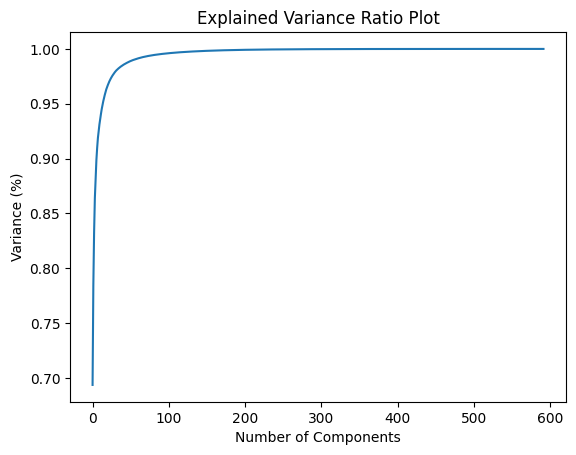

In [ ]:
#Fitting the PCA algorithm with our Data
pca = PCA().fit(all_features)
plt.figure()
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Variance (%)')
plt.title('Explained Variance Ratio Plot')
plt.show()

Dimensionality Reduction

In [ ]:
pca = PCA(n_components=80)
all_features = pca.fit_transform(all_features)

In [ ]:
all_features.shape

(1440, 80)

Saving features in a csv file

In [ ]:
extracted_features_path = './extracted_features.csv'
extracted_df = pd.DataFrame(all_features)
extracted_df['Label'] = labels
extracted_df.to_csv(extracted_features_path, index=False)
extracted_df.head()

,0,1,2,3,4,5,6,7,8,9,...,71,72,73,74,75,76,77,78,79,Label
0,-1.035753,-0.554447,0.915709,-1.133821,-0.087677,-1.256387,-0.913801,-0.613382,1.306627,0.525318,...,0.407938,-0.218563,-0.559516,0.025924,0.314816,-0.096733,-0.490718,-0.524104,-1.231004,Neutral
1,-0.523768,-0.515939,-0.456749,-0.526417,-0.004112,-0.868599,0.826531,0.122965,-0.926636,0.367064,...,1.310658,0.374306,-0.607414,1.075433,1.090447,-0.514674,-0.809060,1.601485,-0.643964,Neutral
2,-0.317998,-0.685548,0.884071,-0.065124,1.184927,-0.728129,-0.914095,-0.337755,0.090119,-0.516736,...,-0.235568,2.566003,-2.414493,1.278376,-0.297549,-2.243084,-0.207261,-0.709435,0.626971,Neutral
3,-0.881924,-1.130598,-0.817955,-0.714845,-0.396817,-0.441315,0.131718,0.199544,-0.682240,-0.827272,...,0.092577,-0.731082,-1.963701,1.751148,1.228549,-1.907209,-0.244303,0.800432,-1.323841,Neutral
4,-1.217496,-1.114643,1.762826,0.757327,-0.278531,-0.897961,0.360851,-0.439028,0.290743,-0.019939,...,0.720097,0.523023,2.726015,1.944865,-0.479433,0.029634,1.020306,-0.407017,-0.519447,Neutral


Standardization

In [ ]:
data = all_features
scaler = StandardScaler()
all_features = scaler.fit_transform(data)

SVM Model

*   Training and Testing using KFold Cross Validation
*   Getting the best model
*   Visualizing the Confusion Matrix of the best model

Fold 1 Accuracy: 0.7638888888888888
Fold 2 Accuracy: 0.8472222222222222
Fold 3 Accuracy: 0.7638888888888888
Fold 4 Accuracy: 0.8611111111111112
Fold 5 Accuracy: 0.8055555555555556
Fold 6 Accuracy: 0.7222222222222222
Fold 7 Accuracy: 0.7916666666666666
Fold 8 Accuracy: 0.8333333333333334
Fold 9 Accuracy: 0.8055555555555556
Fold 10 Accuracy: 0.6527777777777778
Fold 11 Accuracy: 0.7777777777777778
Fold 12 Accuracy: 0.875
Fold 13 Accuracy: 0.9583333333333334
Fold 14 Accuracy: 0.8472222222222222
Fold 15 Accuracy: 0.7361111111111112
Fold 16 Accuracy: 0.7638888888888888
Fold 17 Accuracy: 0.8472222222222222
Fold 18 Accuracy: 0.8194444444444444
Fold 19 Accuracy: 0.8611111111111112
Fold 20 Accuracy: 0.8472222222222222


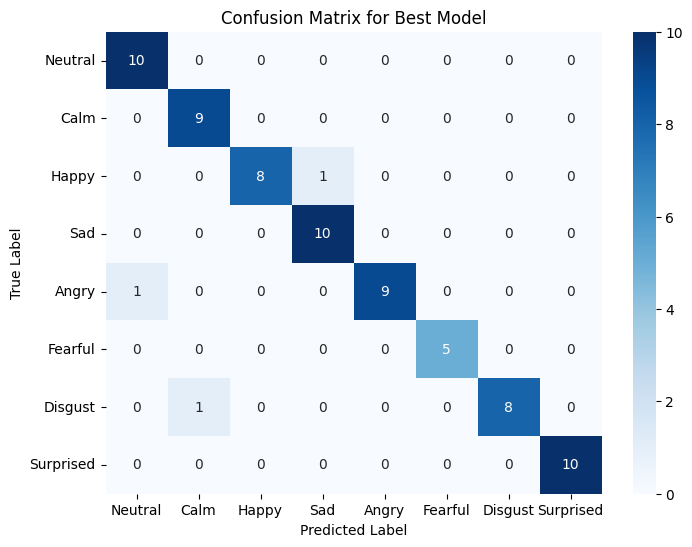

In [ ]:
# SVM model
svm_model = SVC(kernel='rbf', C=3.0, gamma='auto', random_state=42)

# Set up k-fold cross-validation
k_folds = 20
cv = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Track the best model
best_accuracy = 0
best_model = None

# Perform k-fold cross-validation
for fold, (train_idx, test_idx) in enumerate(cv.split(all_features, labels)):
    X_train, X_test = all_features[train_idx], all_features[test_idx]
    y_train, y_test = labels[train_idx], labels[test_idx]

    # Train the model
    svm_model.fit(X_train, y_train)

    # Validate on the current fold
    y_pred = svm_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)

    print(f"Fold {fold + 1} Accuracy: {accuracy}")

    # Check if this model is the best so far
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = svm_model
        best_confusion_matrix = confusion_matrix(y_test, y_pred)


# Visualize the confusion matrix for the best model
plt.figure(figsize=(8, 6))
emotions_names = ["Neutral", "Calm", "Happy", "Sad", "Angry", "Fearful", "Disgust", "Surprised"]
sns.heatmap(best_confusion_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=emotions_names, yticklabels=emotions_names)
plt.title("Confusion Matrix for Best Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Saving the Model

In [ ]:
# Save the best model to a file
model_filename = "best_model.joblib"
joblib.dump(best_model, model_filename)
print(f"Best Model saved as {model_filename}")

Best Model saved as best_model.joblib
